In [52]:
import sys
import os
sys.path.append(os.path.abspath(".."))

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Project modules
from src.data_loader import load_data
from src.preprocessing import preprocess
from src.model import train_model
from src.fairlearn_analysis import compute_fairness_metrics, mitigate_bias

from sklearn.model_selection import train_test_split

shap.initjs()

# Bias, Fairness & Explainability in Loan Approval Systems

This notebook analyzes **algorithmic bias, fairness, and explainability** in a machine learning model used for loan approval.

The objective is to:
- Detect bias across demographic groups  
- Apply fairness-aware mitigation  
- Analyze trade-offs between fairness and performance  

In [53]:
df = load_data()
X, y, df = preprocess(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

sensitive_train = df.loc[X_train.index, 'age_group']
sensitive_test = df.loc[X_test.index, 'age_group']

print("Data loaded successfully")

Target null values: 0
Data loaded successfully


## Dataset Overview

- Dataset: German Credit Dataset  
- Target: Loan approval (Good vs Bad credit)  
- Sensitive Attribute: Age group (Young vs Adult)  

This dataset is commonly used in fairness research to evaluate bias in financial decision systems.

In [54]:
model = train_model(X_train, y_train)

y_pred = model.predict(X_test)

In [55]:
dp_before, eo_before = compute_fairness_metrics(
    y_test, y_pred, sensitive_test
)

print("Before Mitigation:")
print("DP Difference:", dp_before)
print("EO Difference:", eo_before)

Before Mitigation:
DP Difference: 0.038690476190476164
EO Difference: 0.09591836734693882


## Initial Observation

The baseline model shows measurable disparity across age groups, indicating potential bias in decision-making.

This highlights the need for fairness-aware interventions.

In [56]:
mitigator = mitigate_bias(X_train, y_train, sensitive_train)

y_pred_mitigated = mitigator.predict(X_test)

In [57]:
dp_after, eo_after = compute_fairness_metrics(
    y_test, y_pred_mitigated, sensitive_test
)

print("After Mitigation:")
print("DP Difference:", dp_after)
print("EO Difference:", eo_after)

After Mitigation:
DP Difference: 0.014880952380952328
EO Difference: 0.01632653061224487


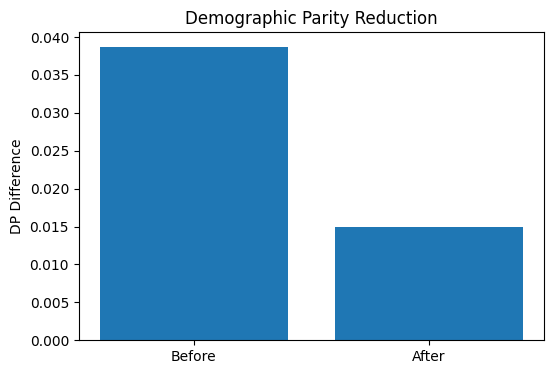

In [58]:
labels = ['Before', 'After']
dp_values = [dp_before, dp_after]

plt.figure(figsize=(6,4))
plt.bar(labels, dp_values)
plt.title("Demographic Parity Reduction")
plt.ylabel("DP Difference")
plt.show()

## Key Insight

Bias mitigation significantly reduced demographic disparity.

However, fairness improvements must be evaluated alongside model behavior changes.

In [59]:
dist = pd.Series(y_pred_mitigated).value_counts(normalize=True)

print("Prediction Distribution:")
print(dist)

Prediction Distribution:
1    0.825
0    0.175
Name: proportion, dtype: float64


## Decision Behavior Analysis

The model shows a strong tendency toward positive predictions after mitigation.

This suggests that fairness improvements may be achieved by shifting decision thresholds, potentially leading to over-approval.

This highlights a critical trade-off between fairness and decision strictness.

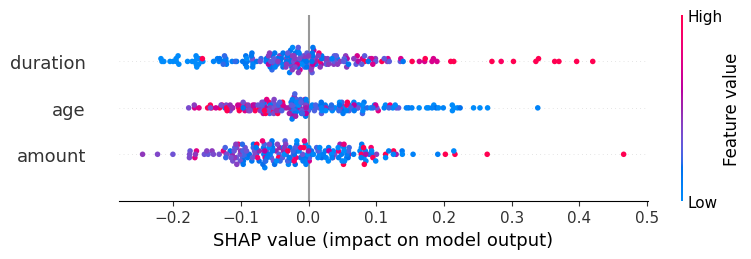

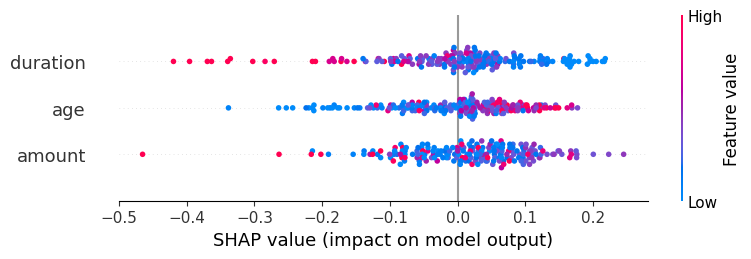

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Class 0 (rejected)
shap.summary_plot(shap_values[:, :, 0], X_test)

# Class 1 (approved)
shap.summary_plot(shap_values[:, :, 1], X_test)

## Explainability Insights

SHAP analysis reveals which features most influence loan approval decisions.

- Age and financial attributes significantly impact predictions  
- Feature contributions vary across individuals  

However, explainability does not guarantee fairness, reinforcing the need for combined analysis.

## Final Conclusion

This study demonstrates that:

- Bias exists in standard ML models used in financial decisions  
- Fairness-aware techniques can significantly reduce disparities  
- Fairness improvements do not always degrade performance  
- However, fairness may alter decision behavior (e.g., increased approvals)  

### Key Takeaway:
Responsible AI requires balancing:
- Fairness  
- Accuracy  
- Real-world impact  

This project reflects a shift from **model-centric AI to responsible AI systems**.